In [5]:
!pip install pandas numpy matplotlib seaborn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [11]:
# style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['font.family'] = 'sans-serif'
# Load data
df = pd.read_csv(r"C:\Users\dell\Downloads\incidents-and-trafficking-database-2025.csv")
df['Date'] = pd.to_datetime(df['Year'], format='%Y')
print("="*80)
print("IAEA NUCLEAR SECURITY INCIDENT DATABASE - COMPLETE ANALYSIS")
print("="*80)
print(f"Years covered: {df['Year'].min()} to {df['Year'].max()}")
print(f"Total incidents: {df['Total'].sum():,}")
print(df.head())

IAEA NUCLEAR SECURITY INCIDENT DATABASE - COMPLETE ANALYSIS
Years covered: 1993 to 2025
Total incidents: 4,626
   Year  Group I  Group II  Group III  Total       Date
0  1993       12         6          2     20 1993-01-01
1  1994       15         3          0     18 1994-01-01
2  1995       17        10          2     29 1995-01-01
3  1996       13        48         11     72 1996-01-01
4  1997       12        52          7     71 1997-01-01


In [13]:
# STATISTICS
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)

recent_avg = df[df['Year'] >= 2020]['Total'].mean()
past_avg = df[df['Year'] <= 2000]['Total'].mean()
print(f"Average incidents (1993-2000): {past_avg:.0f}")
print(f"Average incidents (2020-2025): {recent_avg:.0f}")
print(f"Change: +{recent_avg - past_avg:.0f} incidents/year")

print(f"\nHighest incident year: {df.loc[df['Total'].idxmax(), 'Year']} ({df['Total'].max()} incidents)")
print(f"Lowest incident year: {df.loc[df['Total'].idxmin(), 'Year']} ({df['Total'].min()} incidents)")

nuclear_total = df['Group I'].sum()
print(f"\nTotal nuclear material incidents (Group I): {nuclear_total}")


BASIC STATISTICS
Average incidents (1993-2000): 47
Average incidents (2020-2025): 157
Change: +110 incidents/year

Highest incident year: 2007 (273 incidents)
Lowest incident year: 1994 (18 incidents)

Total nuclear material incidents (Group I): 359


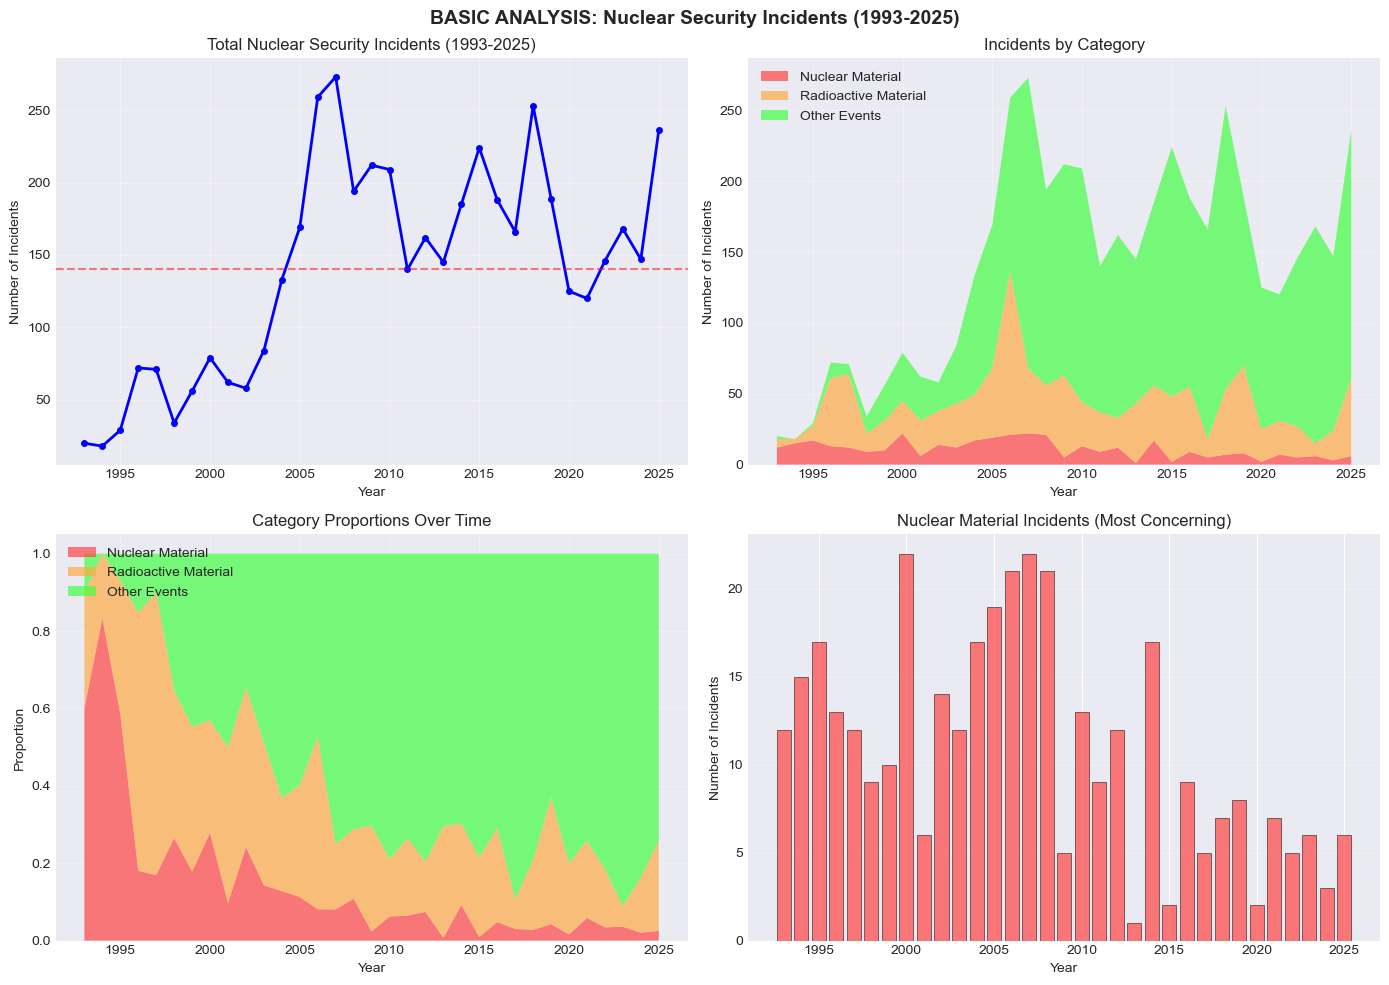


✅ Basic analysis complete. Saved: nuclear_incident_basic_analysis.png


In [15]:
# VISUALIZATIONS

fig1, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total incidents over time
axes[0,0].plot(df['Year'], df['Total'], 'b-o', linewidth=2, markersize=4)
axes[0,0].axhline(y=df['Total'].mean(), color='r', linestyle='--', alpha=0.5)
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Incidents')
axes[0,0].set_title('Total Nuclear Security Incidents (1993-2025)')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Stacked area by category
axes[0,1].stackplot(df['Year'], df['Group I'], df['Group II'], df['Group III'],
                    labels=['Nuclear Material', 'Radioactive Material', 'Other Events'],
                    colors=['#ff4444', '#ffaa44', '#44ff44'], alpha=0.7)
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Number of Incidents')
axes[0,1].set_title('Incidents by Category')
axes[0,1].legend(loc='upper left')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Category proportions
category_pcts = df[['Group I', 'Group II', 'Group III']].values
category_pcts = category_pcts / category_pcts.sum(axis=1, keepdims=True)
axes[1,0].stackplot(df['Year'], category_pcts.T,
                    labels=['Nuclear Material', 'Radioactive Material', 'Other Events'],
                    colors=['#ff4444', '#ffaa44', '#44ff44'], alpha=0.7)
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Proportion')
axes[1,0].set_title('Category Proportions Over Time')
axes[1,0].legend(loc='upper left')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Nuclear material incidents only
axes[1,1].bar(df['Year'], df['Group I'], color='#ff4444', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Number of Incidents')
axes[1,1].set_title('Nuclear Material Incidents (Most Concerning)')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('BASIC ANALYSIS: Nuclear Security Incidents (1993-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nuclear_incident_basic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Basic analysis complete. Saved: nuclear_incident_basic_analysis.png")

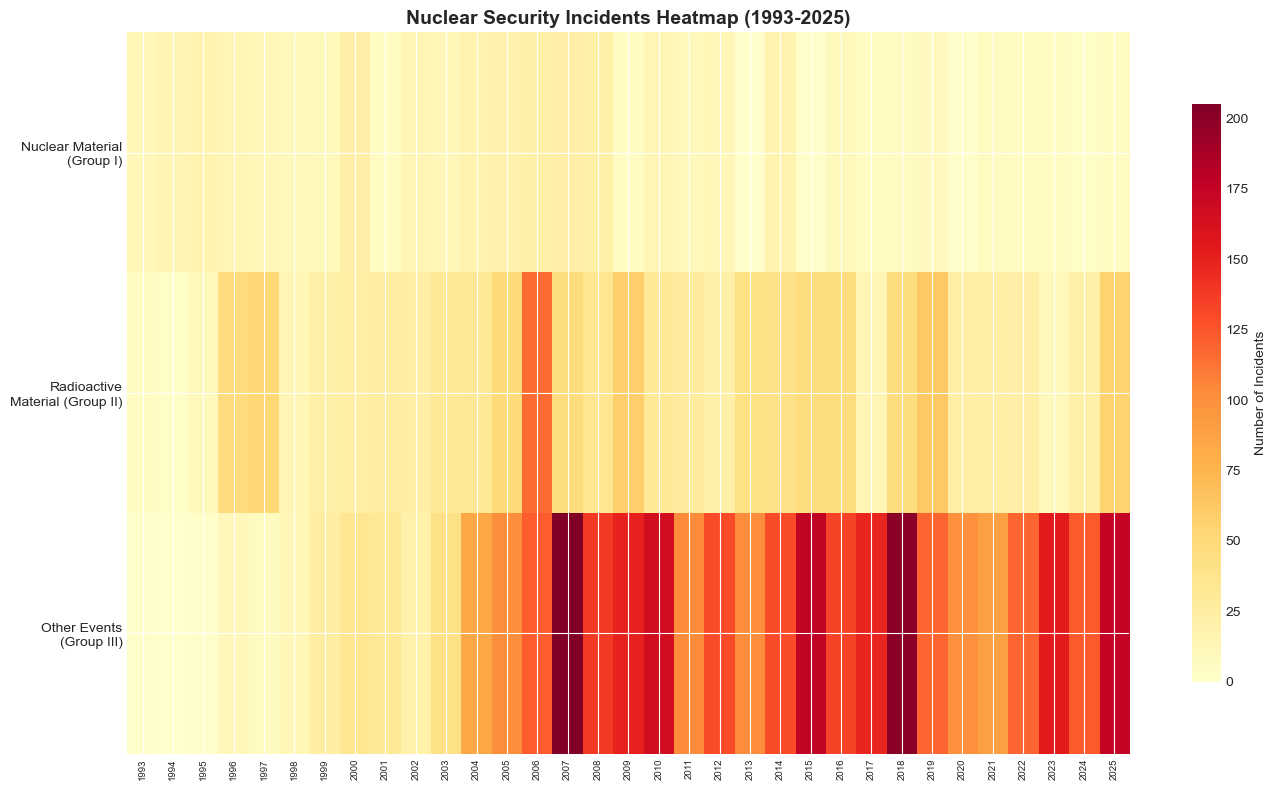

✅ Heatmap saved: nuclear_incident_heatmap.png


C:\Users\dell\AppData\Local\Temp\ipykernel_2820\552282834.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


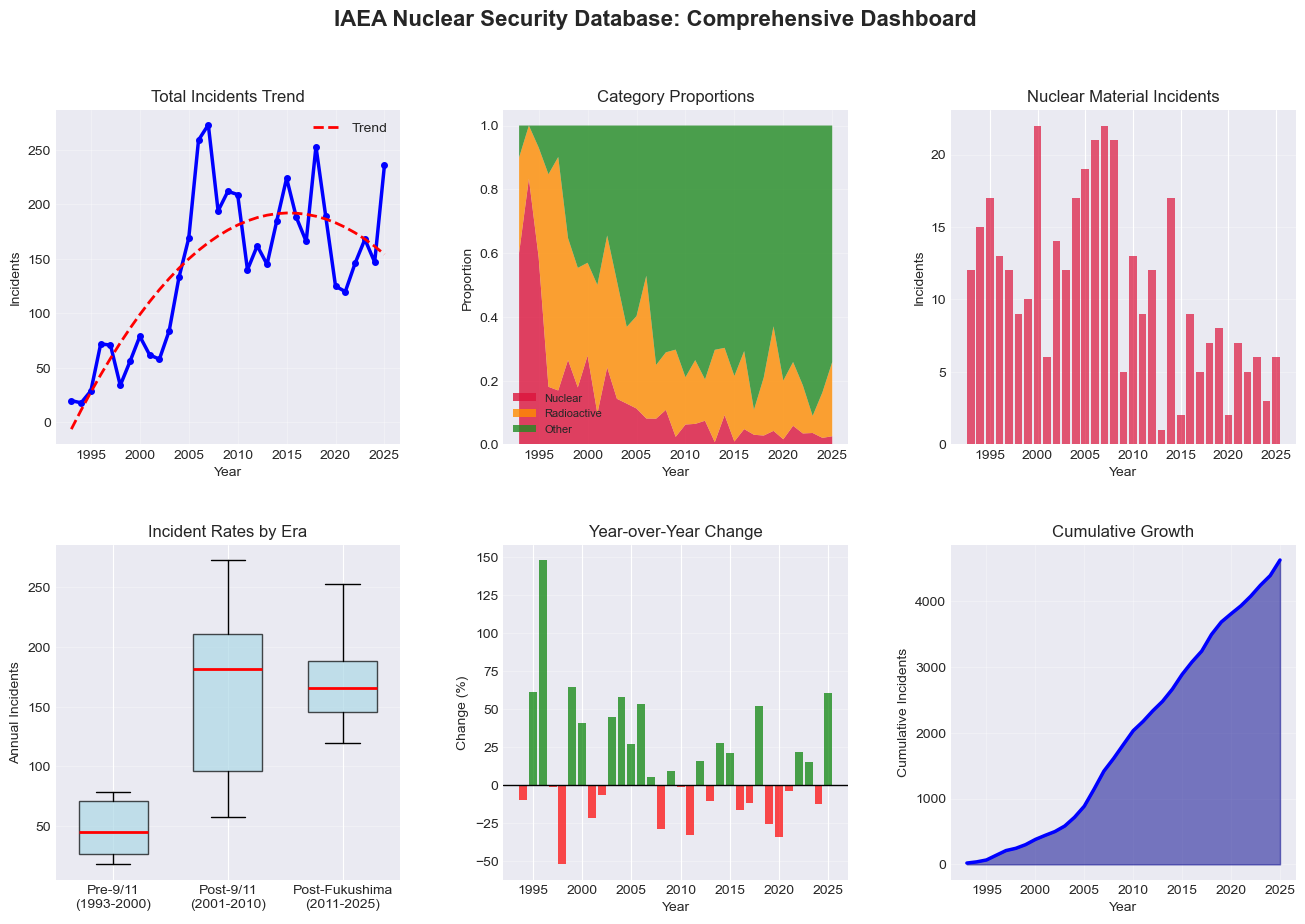

✅ Dashboard saved: nuclear_incident_dashboard.png


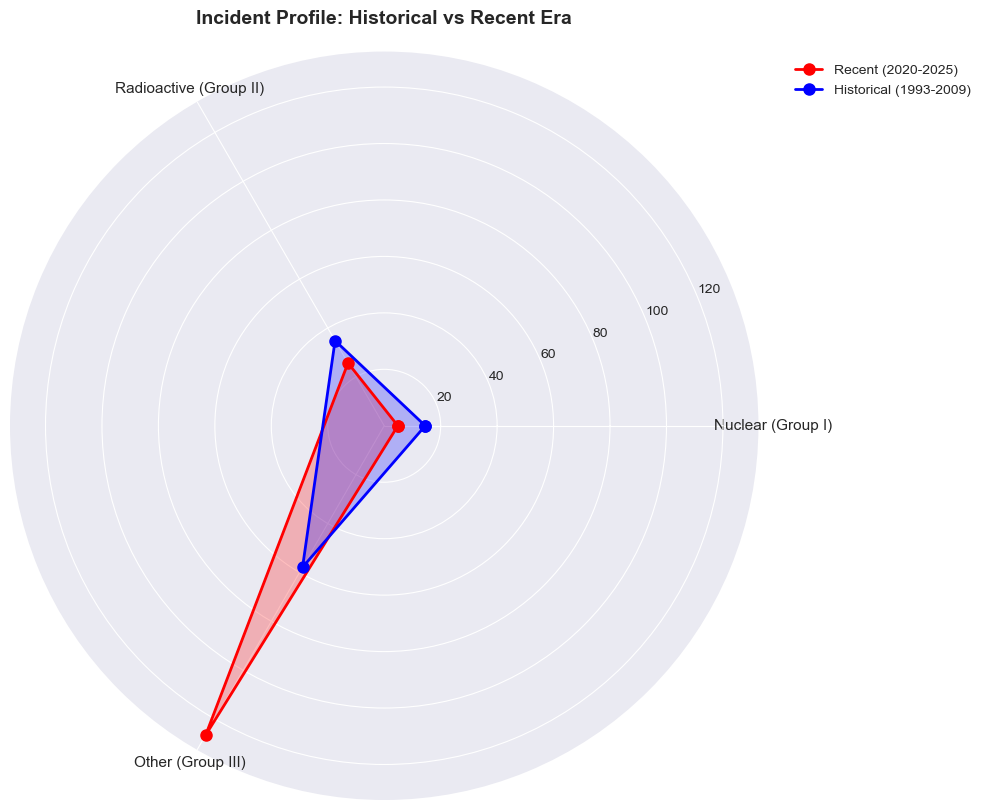

✅ Radar chart saved: nuclear_incident_radar.png

PROJECT COMPLETE - SUMMARY OF OUTPUTS

✅ FILES GENERATED:
   1. nuclear_incident_basic_analysis.png  (4 basic plots)
   2. nuclear_incident_heatmap.png          (30-year heatmap)
   3. nuclear_incident_dashboard.png        (6-panel dashboard)
   4. nuclear_incident_radar.png            (Era comparison radar)

📊 KEY FINDINGS:
   • Total incidents (1993-2025): 4,626
   • Peak year: 2007 (273 incidents)
   • Nuclear material incidents: 359



In [19]:
# HEATMAP VISUALIZATION

fig2, ax = plt.subplots(figsize=(14, 8))

heatmap_data = df[['Group I', 'Group II', 'Group III']].T
years = df['Year'].astype(str).tolist()

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xticks(np.arange(len(years)))
ax.set_yticks(np.arange(3))
ax.set_xticklabels(years, rotation=90, fontsize=7)
ax.set_yticklabels(['Nuclear Material\n(Group I)', 'Radioactive\nMaterial (Group II)', 'Other Events\n(Group III)'], fontsize=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Number of Incidents', fontsize=10)

ax.set_title('Nuclear Security Incidents Heatmap (1993-2025)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('nuclear_incident_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Heatmap saved: nuclear_incident_heatmap.png")


# PANEL DASHBOARD

fig3 = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig3, hspace=0.3, wspace=0.3)

# Panel 1: Total incidents with trend
ax1 = fig3.add_subplot(gs[0, 0])
ax1.plot(df['Year'], df['Total'], 'b-', linewidth=2.5, marker='o', markersize=4)
z = np.polyfit(df['Year'], df['Total'], 2)
p = np.poly1d(z)
ax1.plot(df['Year'], p(df['Year']), 'r--', linewidth=2, label='Trend')
ax1.set_xlabel('Year')
ax1.set_ylabel('Incidents')
ax1.set_title('Total Incidents Trend')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Category proportions
ax2 = fig3.add_subplot(gs[0, 1])
ax2.stackplot(df['Year'], category_pcts.T,
              labels=['Nuclear', 'Radioactive', 'Other'],
              colors=['#DC143C', '#FF8C00', '#228B22'], alpha=0.8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Proportion')
ax2.set_title('Category Proportions')
ax2.legend(loc='lower left', fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: Nuclear material incidents
ax3 = fig3.add_subplot(gs[0, 2])
ax3.bar(df['Year'], df['Group I'], color='#DC143C', alpha=0.7)
ax3.set_xlabel('Year')
ax3.set_ylabel('Incidents')
ax3.set_title('Nuclear Material Incidents')
ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: Era comparison
ax4 = fig3.add_subplot(gs[1, 0])
pre_911 = df[df['Year'] < 2001]['Total']
post_911 = df[(df['Year'] >= 2001) & (df['Year'] < 2011)]['Total']
post_fukushima = df[df['Year'] >= 2011]['Total']
ax4.boxplot([pre_911, post_911, post_fukushima], positions=[1,2,3], widths=0.6,
            patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax4.set_xticklabels(['Pre-9/11\n(1993-2000)', 'Post-9/11\n(2001-2010)', 'Post-Fukushima\n(2011-2025)'])
ax4.set_ylabel('Annual Incidents')
ax4.set_title('Incident Rates by Era')
ax4.grid(True, alpha=0.3, axis='y')

# Panel 5: Year-over-year change
ax5 = fig3.add_subplot(gs[1, 1])
pct_change = df['Total'].pct_change() * 100
colors = ['green' if x >= 0 else 'red' for x in pct_change[1:]]
ax5.bar(df['Year'][1:], pct_change[1:], color=colors, alpha=0.7)
ax5.axhline(y=0, color='black', linewidth=1)
ax5.set_xlabel('Year')
ax5.set_ylabel('Change (%)')
ax5.set_title('Year-over-Year Change')
ax5.grid(True, alpha=0.3, axis='y')

# Panel 6: Cumulative incidents
ax6 = fig3.add_subplot(gs[1, 2])
cumulative = df['Total'].cumsum()
ax6.fill_between(df['Year'], cumulative, alpha=0.5, color='darkblue')
ax6.plot(df['Year'], cumulative, 'b-', linewidth=2.5)
ax6.set_xlabel('Year')
ax6.set_ylabel('Cumulative Incidents')
ax6.set_title('Cumulative Growth')
ax6.grid(True, alpha=0.3)

plt.suptitle('IAEA Nuclear Security Database: Comprehensive Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('nuclear_incident_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Dashboard saved: nuclear_incident_dashboard.png")


# RADAR CHART

fig4, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

categories = ['Nuclear (Group I)', 'Radioactive (Group II)', 'Other (Group III)']
recent_avg = [df[df['Year'] >= 2020]['Group I'].mean(),
              df[df['Year'] >= 2020]['Group II'].mean(),
              df[df['Year'] >= 2020]['Group III'].mean()]
historical_avg = [df[df['Year'] < 2010]['Group I'].mean(),
                  df[df['Year'] < 2010]['Group II'].mean(),
                  df[df['Year'] < 2010]['Group III'].mean()]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
recent_avg += recent_avg[:1]
historical_avg += historical_avg[:1]
angles += angles[:1]

ax.plot(angles, recent_avg, 'o-', linewidth=2, label='Recent (2020-2025)', color='red', markersize=8)
ax.fill(angles, recent_avg, alpha=0.25, color='red')
ax.plot(angles, historical_avg, 'o-', linewidth=2, label='Historical (1993-2009)', color='blue', markersize=8)
ax.fill(angles, historical_avg, alpha=0.25, color='blue')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Incident Profile: Historical vs Recent Era', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('nuclear_incident_radar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Radar chart saved: nuclear_incident_radar.png")

# SUMMARY

print("\n" + "="*80)
print("PROJECT COMPLETE - SUMMARY OF OUTPUTS")
print("="*80)
print("""
✅ FILES GENERATED:
   1. nuclear_incident_basic_analysis.png  (4 basic plots)
   2. nuclear_incident_heatmap.png          (30-year heatmap)
   3. nuclear_incident_dashboard.png        (6-panel dashboard)
   4. nuclear_incident_radar.png            (Era comparison radar)

📊 KEY FINDINGS:
   • Total incidents (1993-2025): {:,}
   • Peak year: {} ({} incidents)
   • Nuclear material incidents: {}
""".format(df['Total'].sum(), 
           df.loc[df['Total'].idxmax(), 'Year'], 
           df['Total'].max(), 
           nuclear_total))

